# **Iris Classification**

## **1. Introduction**

The Iris Flower Dataset is one of the most well-known and beginner-friendly datasets in the field of machine learning and data analysis. Introduced by British biologist and statistician Ronald A. Fisher in 1936, this dataset is often used for classification and clustering problems. It contains measurements of different features of iris flowers from three distinct species and is commonly used to illustrate basic principles of pattern recognition and classification.

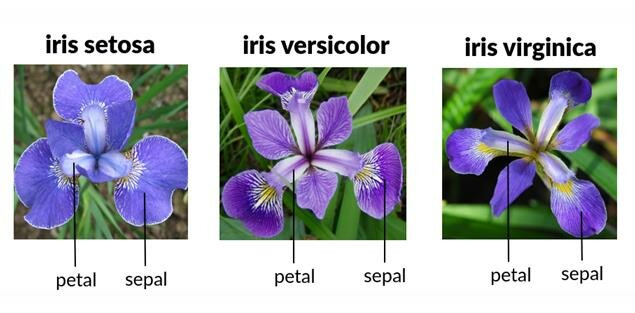

## **2. About the Dataset**

The Iris dataset consists of 150 samples of iris flowers collected from three species:

Iris-setosa

Iris-versicolor

Iris-virginica

Each sample includes four numerical features:

SepalLengthCm - Length of the sepal (in centimeters)

SepalWidthCm  -Width of the sepal (in centimeters)

PetalLengthCm -  Length of the petal (in centimeters)

PetalWidthCm - Width of the petal (in centimeters)

id - unique identifier for each flower sample.

## **3. Importing the Dependencies**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor




## **4. Data Collection & Preprocessing**

In [ ]:
iris_data = pd.read_csv(r"iris.csv")

In [ ]:
iris_data.head(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## **5. Check for missing Data**

In [ ]:
iris_data.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


No missing values found in the dataset.

## **6. Print the dimension of the dataset.**

In [ ]:
iris_data.shape

(150, 6)

The dataset contains 150 rows and 6 columns.

## **7. Print Statistical summary using the description.**

In [ ]:
iris_data.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


The dataset shows a consistent distribution with Sepal and Petal lengths and widths varying by species.

## **8. Print the range of the SepalLengthCm**

In [ ]:
SepalLengthRange= iris_data['SepalLengthCm'].max() - iris_data['SepalLengthCm'].min()

In [ ]:
print(SepalLengthRange)

3.6000000000000005


## **9. Print the range of the SepalWidthCm**

In [ ]:
SepalWidthRange = iris_data['SepalWidthCm'].max() - iris_data['SepalWidthCm'].min()

In [ ]:
print(SepalWidthRange)

2.4000000000000004


## **10. Print the range of the PetalLengthCm**

In [ ]:
PetalLengthCmRange = iris_data['PetalLengthCm'].max() - iris_data['PetalLengthCm'].min()

In [ ]:
print(PetalLengthCmRange)

5.9


## **11. Print the range of the PetalWidthCm**

In [ ]:
PetalWidthCmRange = iris_data['PetalWidthCm'].max() - iris_data['PetalWidthCm'].min()

In [ ]:
print(PetalWidthCmRange)

2.4


## **12. Is this a classification or regression problem? Explain?**

The Iris dataset is a classification problem, not a regression problem.

The goal is to predict the species of an iris flower (Iris-setosa, Iris-versicolor, or Iris-virginica) based on its features like sepal length, sepal width, petal length, and petal width.

The target variable Species is categorical, not numerical or continuous.



In [ ]:
iris_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
iris_data.dtypes

,0
Id,int64
SepalLengthCm,float64
SepalWidthCm,float64
PetalLengthCm,float64
PetalWidthCm,float64
Species,object


# **13. EDA**

# **13(a). Bar Plot**

Text(0, 0.5, 'Count')

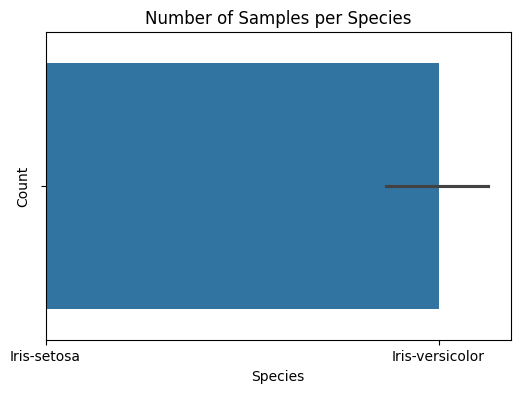

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(data=iris_data, x='Species')
plt.title('Number of Samples per Species')
plt.xlabel('Species')
plt.ylabel('Count')

This bar plot shows how many samples are present for each species. The dataset is balanced with exactly 50 samples of each Iris species — Setosa, Versicolor, and Virginica.

# **13(b). Scatter Plot**

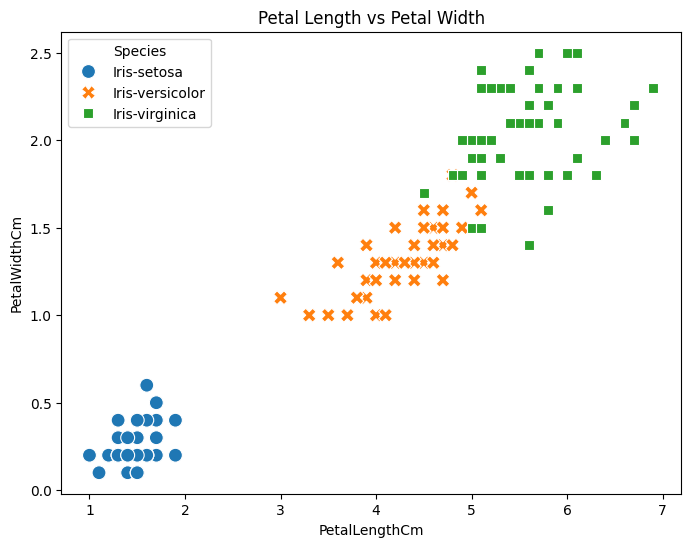

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=iris_data, x='PetalLengthCm', y='PetalWidthCm', hue='Species', style='Species', s=100)
plt.title('Petal Length vs Petal Width')
plt.show()


Scatter plot shows a very clear separation of species based on petal size. This is one of the best feature pairs to distinguish Iris species.

# 3. **13(c). Box Plot**

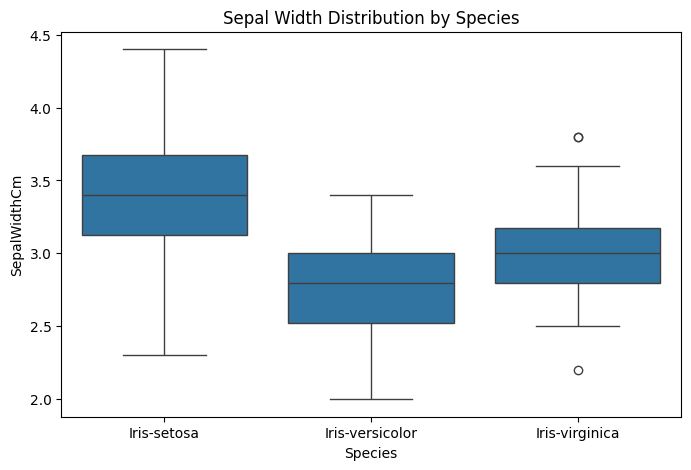

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=iris_data, x='Species', y='SepalWidthCm')
plt.title('Sepal Width Distribution by Species')
plt.show()

Box plot shows the range and median of sepal widths by species. Iris-setosa tends to have wider sepals, helping distinguish it from other species.

# **13(d). Histogram**

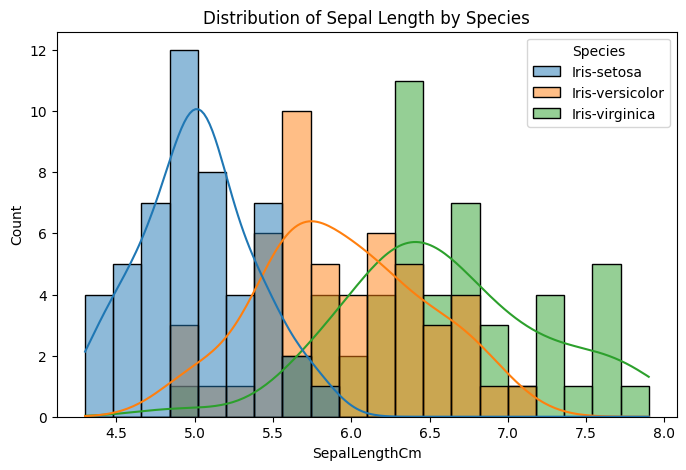

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=iris_data, x='SepalLengthCm', hue='Species', kde=True, bins=20)
plt.title('Distribution of Sepal Length by Species')
plt.show()

Shows the frequency distribution of sepal lengths for each species.

# **13(e). Correlation Heatmap**

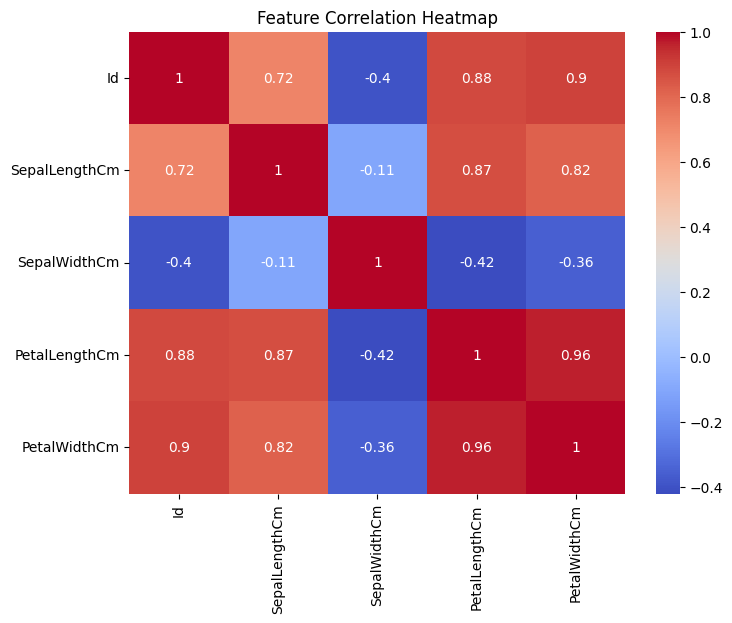

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(iris_data.iloc[:, :-1].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

PetalLengthCm and PetalWidthCm are strongly positively correlated (0.96).
SepalWidthCm shows weak or negative correlation with other features.

# **13(f). Box Plot**

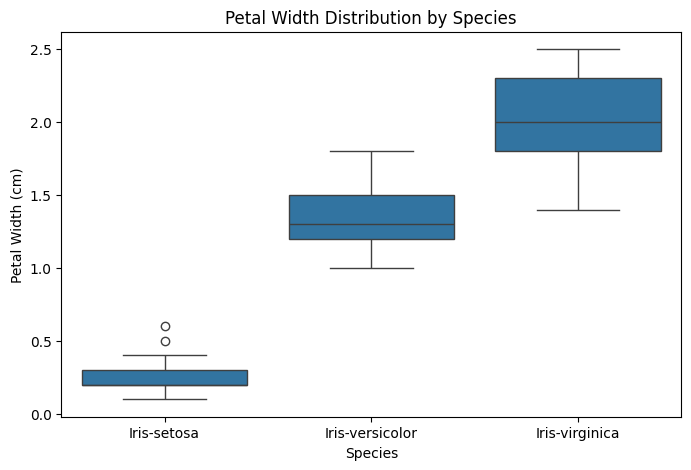

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=iris_data, x='Species', y='PetalWidthCm')
plt.title('Petal Width Distribution by Species')
plt.xlabel('Species')
plt.ylabel('Petal Width (cm)')
plt.show()


Iris-setosa has the smallest petal width with low variation.
Iris-virginica shows the largest petal width values.
There's clear separation between species, helpful for classification.

# **13(g). Bar Plots**

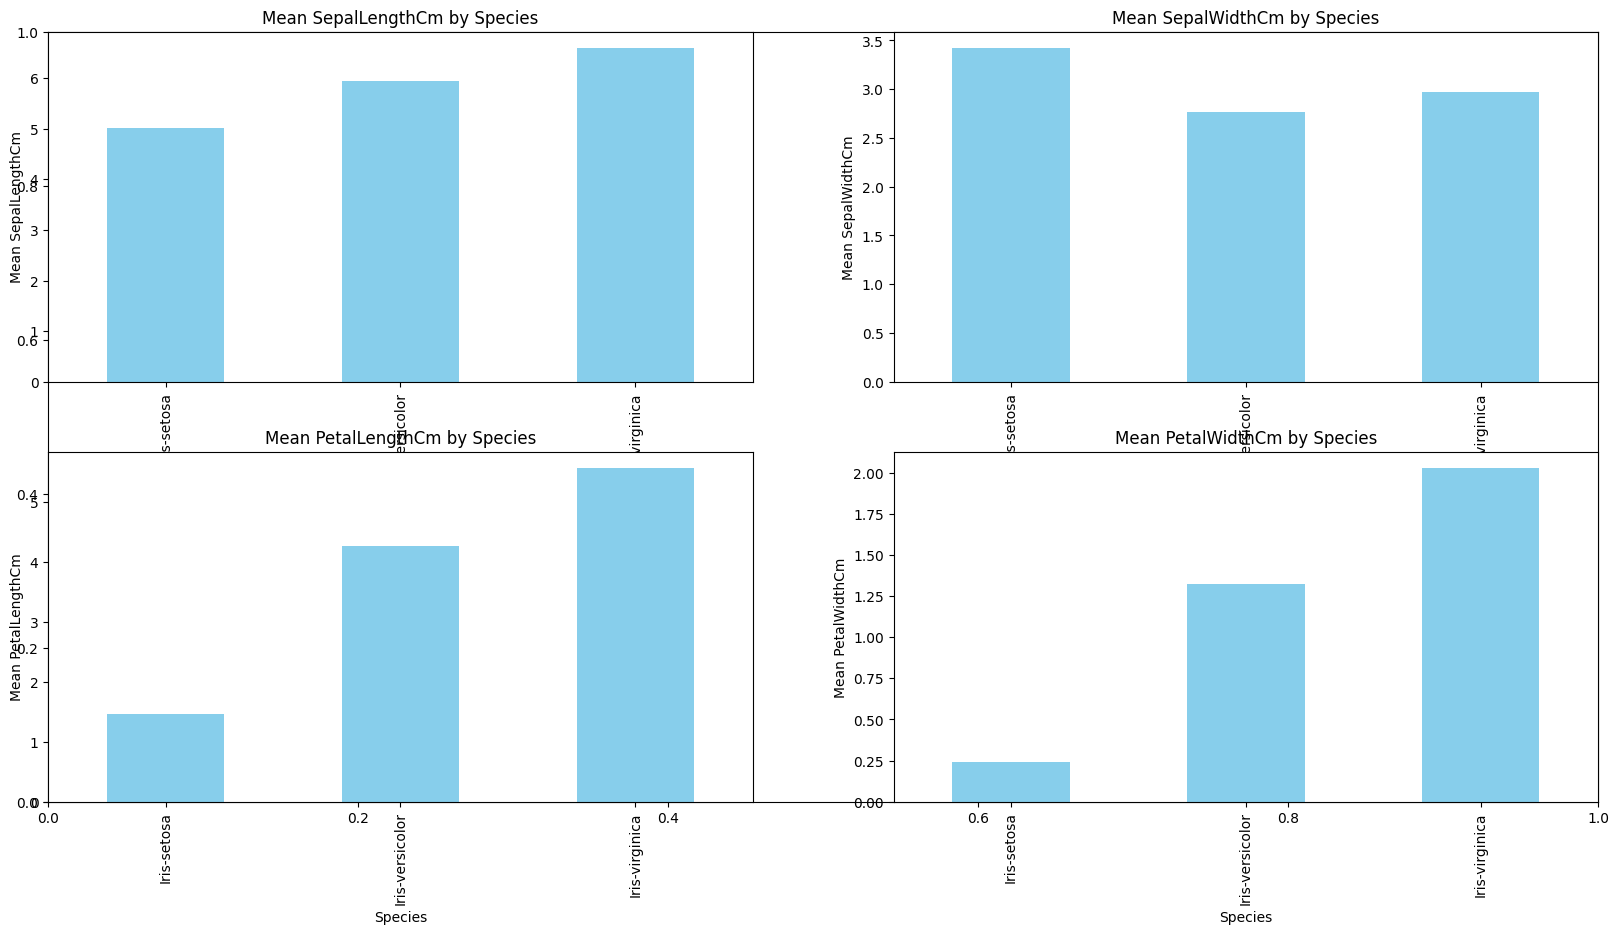

In [ ]:
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

plt.subplots(figsize=(20,10))

for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    iris_data.groupby('Species')[col].mean().plot(kind='bar', color='skyblue')
    plt.title(f'Mean {col} by Species')
    plt.ylabel(f'Mean {col}')
    plt.xlabel('Species')

plt.show()


Iris-virginica has the highest mean petal and sepal lengths.
Iris-setosa stands out with the highest mean SepalWidthCm.
Mean PetalWidthCm increases clearly from setosa → versicolor → virginica.

# **14. Dropping the Unwanted Column**

In [ ]:
iris_data.head(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
iris_data.drop(['Id'],axis = 1, inplace = True)

In [ ]:
iris_data.head(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


# **15. Encoding the Categorical Columns**

In [ ]:
iris_data['Species'].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [ ]:
iris_data.replace({'Species': {'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2}})

<ipython-input-28-2415799000>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  iris_data.replace({'Species': {'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2}})


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


To prepare the dataset for machine learning, the categorical target variable Species was converted into numerical format using label encoding.  The species names were replaced with integer values: Iris-setosa was encoded as 0, Iris-versicolor as 1, and Iris-virginica as 2.

In [ ]:
iris_datas = iris_data.replace({'Species': {'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2}})

<ipython-input-29-3537143301>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  iris_datas = iris_data.replace({'Species': {'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2}})


# **16. Separating the Features and Targets**

In [ ]:
feature = iris_datas.drop(['Species'],axis = 1)
target = iris_datas['Species'].values

In [ ]:
feature.head(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
print(target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


# **17. Splitting the data into training data & Test data**

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(feature, target, test_size=0.4, random_state=2)


In [ ]:
print(X_train.shape)
print(X_test.shape)

(90, 4)
(60, 4)


# **18. Model Training**

In [ ]:
scalar = StandardScaler()

X_train = scalar.fit_transform(X_train)
X_test=scalar.transform(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error as mae
models = [LinearRegression(), XGBRegressor(), Lasso(),RandomForestRegressor(),Ridge()]

for i in range(5):
  models[i].fit(X_train,Y_train)

  print(f'{models[i]} : ')

  train_preds = models[i].predict(X_train)
  print('Training Error : ',mae(Y_train,train_preds))

  test_preds = models[i].predict(X_test)
  print('Validation Error :', mae(Y_test,test_preds))
  print()

LinearRegression() : 
Training Error :  0.16651099673334077
Validation Error : 0.16422976695651195

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...) : 
Training Error :  0.00026736577274277806
Validation Error : 0.05695074424147606

Lasso() : 
Training Error :  0.6301234567901234
Validation Error : 0.

# **19. Performance of the Model**

As tested different machine learning models to predict the species of Iris flowers based on their features. Among all the models, XGBoost Regressor gave the best results. It had the lowest prediction error, which means it was very accurate both during training and testing. Random Forest Regressor also worked well and was very close to XGBoost in performance. Models like Linear Regression and Ridge did okay, but not as good. Lasso Regression performed the worst and was not suitable for this problem. So overall, XGBoost is the best model for making accurate predictions in this Iris flower dataset.